In [5]:
# %%
# =============================================================================
# Célula 1: Imports Essenciais e Definição de Arquivos
# =============================================================================
import os
import matplotlib.pyplot as plt # Apenas se for plotar no final
import pandas as pd # Apenas se for exibir DFs no final
import time # Apenas se quiser medir o tempo total do notebook

# --- Import Principal ---
try:
    from activetextclassification.management.experiment_manager import ExperimentManager
    print("ExperimentManager importado com sucesso.")
except ModuleNotFoundError as e:
    print(f"ERRO CRÍTICO: Falha ao importar ExperimentManager: {e}")
    print("Verifique a estrutura da biblioteca e a instalação.")
    raise e
except Exception as e:
    print(f"ERRO inesperado durante importação: {e}")
    raise e

# --- Autoreload ---
try:
    %load_ext autoreload
    %autoreload 2
    print("Autoreload ativado.")
except Exception: pass

# --- Arquivos ---
CONFIG_FILE = "experiments.json"
HISTORY_LOG_FILE = "history_log.jsonl"
print(f"Arquivo de Configuração: {CONFIG_FILE}")
print(f"Arquivo de Log: {HISTORY_LOG_FILE}")

ExperimentManager importado com sucesso.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Autoreload ativado.
Arquivo de Configuração: experiments.json
Arquivo de Log: history_log.jsonl


In [6]:
# %%
# =============================================================================
# Célula 2: Instanciar e Executar o Gerenciador de Experimentos
# =============================================================================
notebook_start_time = time.time()

print("\n--- Iniciando Gerenciador de Experimentos ---")
# Instanciar o manager, passando os caminhos
manager = ExperimentManager(
    config_file_path=CONFIG_FILE,
    history_log_path=HISTORY_LOG_FILE
)

# Carregar as configurações e o histórico anterior
manager.load_and_prepare()

# Executar todos os experimentos pendentes (ativos e não concluídos)
# O próprio método run_pending_experiments agora imprime logs e o sumário final
try:
     manager.run_pending_experiments(force_rerun=False) # Mude para True para re-rodar tudo
except KeyboardInterrupt:
     print("\nExecução do Gerenciador Interrompida.")
except Exception as run_e:
     print(f"\nERRO CRÍTICO durante a execução dos experimentos pelo Manager: {run_e}")
     traceback.print_exc()


notebook_end_time = time.time()
print(f"\nTempo total de execução do notebook: {notebook_end_time - notebook_start_time:.2f} segundos.")


--- Iniciando Gerenciador de Experimentos ---
HistoryManager inicializado para o arquivo: d:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\Tese-Vers-o-Draft\code\codigos\falco_library\examples\history_log.jsonl
ExperimentManager inicializado.
 - Arquivo de Configuração: d:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\Tese-Vers-o-Draft\code\codigos\falco_library\examples\experiments.json
 - Arquivo de Histórico: d:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\Tese-Vers-o-Draft\code\codigos\falco_library\examples\history_log.jsonl

--- Carregando Configurações e Histórico ---
Configurações de 1 experimentos carregadas de experiments.json.
Lendo histórico de execuções de: history_log.jsonl
Arquivo de histórico lido. Encontrados 13 experimentos 'COMPLETED'.

=============== Iniciando Execução de Experimentos ===============
Total de configurações encontradas: 1
Execuções 'COMPLETED' anteriores a serem puladas: 13

>>> Verificando Experimento 1/1: RND1000

AL Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Iteração 1/1000 ---
L: 1000 (0.8% U original), U: 124183
Aviso: Split interno não estratificado.
Preparando texto bruto para Treino/Teste/P/U...
Model Factory: Criando tipo 'PVBin' com params: {'method': 'binary', 'query': 'binary', 'norm': None, 'query_norm': None, 'ngram_range': [1, 2]}
Model Factory (PVBin): Convertido ngram_range [1, 2] para tupla (1, 2)
Treinando ProductVectorizerClassifier em 700 amostras...
Fitting ProductVectorizerClassifier com 700 amostras...
Fit concluído.
Tempo Treino: 0.16 seg
Interna: Acc=0.5433 F1=0.0758 | Externa: Acc=0.5323 F1=0.1533 (Eval Time: 10.22s)
Calculando probabilidades para U (124183 amostras)...
Seleção (LCO, 10000 amostras): 5.40 seg
Consultando oráculo (Simulated) para 10000 amostras...
Oráculo Simulado: Obtendo rótulos para 10000 amostras...
Oráculo retornou 10000 rótulos válidos.
Verbose: Logando 10000 amostras rotuladas...
Duração Iteração Total: 17.45 seg

--- Iteração 2/1000 ---
L: 11000 (8.8% U original), U: 114183
Aviso: Split 


--- Tentando plotar: RND1000-PVBin2-LCO_Q10000-PER-B100t ---

--- Gerando Gráficos de Curvas de Aprendizado ---


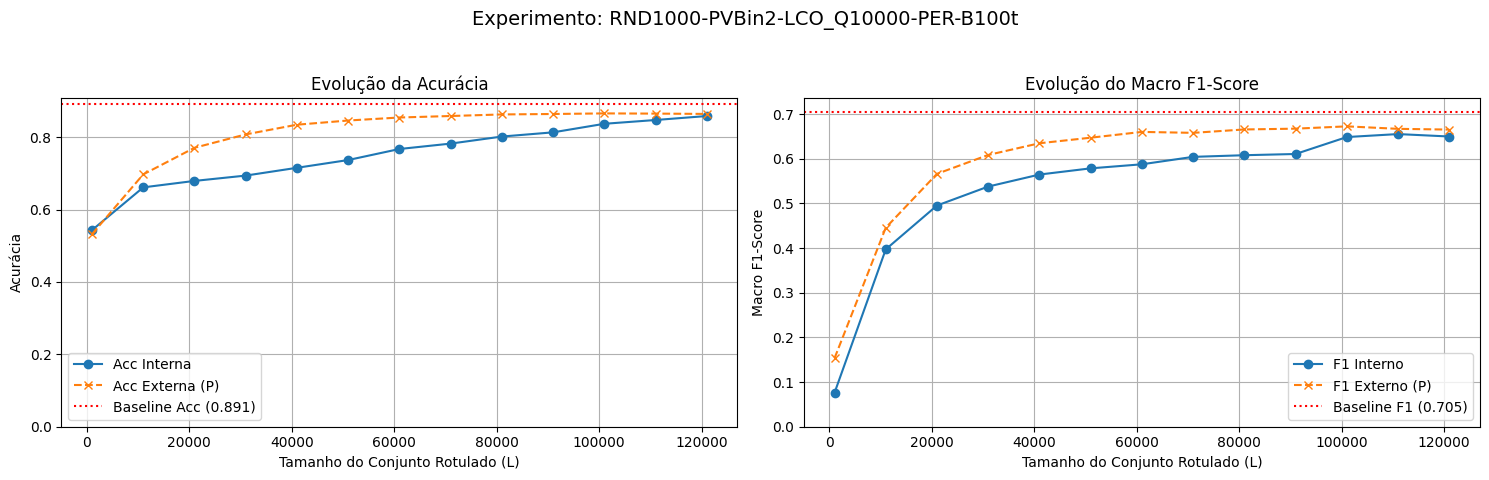

In [7]:
# %%
# =============================================================================
# Célula 3: (Opcional) Análise e Visualização Pós-Execução
# =============================================================================
# Você pode usar os métodos do manager para analisar resultados específicos

# Exemplo: Plotar um experimento específico que acabou de rodar (ou rodou antes)
EXPERIMENT_TO_PLOT = "RND1000-PVBin2-LCO_Q10000-PER-B100t" # <<< Mude aqui
print(f"\n--- Tentando plotar: {EXPERIMENT_TO_PLOT} ---")
try:
     # Opcional: Adicionar método de plotagem ao manager ou usar history_mgr diretamente
     # manager.plot_experiment_results(EXPERIMENT_TO_PLOT, figsize=(12,4))
     # Ou obter os dados e chamar a função de visualização
     history_df_plot = manager.get_experiment_history_df(EXPERIMENT_TO_PLOT)
     results_entry = manager.get_experiment_result(EXPERIMENT_TO_PLOT)
     if history_df_plot is not None and not history_df_plot.empty:
          from activetextclassification.visualization import plot_learning_curves
          plot_learning_curves(
               history_df=history_df_plot,
               baseline_metrics=results_entry.get('baseline_metrics',{}),
               experiment_name=EXPERIMENT_TO_PLOT
          )
     else:
          print(f"Não foi possível plotar, histórico não encontrado ou vazio para {EXPERIMENT_TO_PLOT}")
except Exception as plot_e:
     print(f"Erro ao plotar {EXPERIMENT_TO_PLOT}: {plot_e}")

In [1]:
# Célula para explorar a relação L0 vs Nc_otimo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Seus dados observados do AG
data_ag_nc = {
    'L0_size': np.array([10, 50, 100, 250, 500, 1000, 2500, 5000]),
    'Nc_otimo': np.array([10, 41, 62, 123, 180, 267, 367, 439]) # Usando 62 para L0=100
}
df_ag_nc = pd.DataFrame(data_ag_nc)

# Número total de classes no seu U0 (df_U0_full_original)
N_CLASSES_TOTAL_U0 = df_U0_full_original[LABEL_COLUMN].nunique() # ~622
N_U0_TOTAL = len(df_U0_full_original) # ~175k

# 1. Visualizar
plt.figure(figsize=(8, 5))
plt.plot(df_ag_nc['L0_size'], df_ag_nc['Nc_otimo'], marker='o', linestyle='-', label='Nc Ótimo do AG')
plt.plot(df_ag_nc['L0_size'], np.sqrt(df_ag_nc['L0_size']), marker='x', linestyle='--', label='sqrt(L0_size)')
plt.plot(df_ag_nc['L0_size'], df_ag_nc['L0_size'], marker='s', linestyle=':', label='L0_size (Limite Superior Trivial)')

# Plotar o número total de classes como um limite horizontal
plt.axhline(N_CLASSES_TOTAL_U0, color='grey', linestyle='-.', label=f'N Total Classes U0 ({N_CLASSES_TOTAL_U0})')

plt.xlabel('Tamanho do L0 (I)')
plt.ylabel('Número de Clusters (Nc)')
plt.xscale('log') # Escala log no X pode ajudar a ver a tendência
plt.yscale('log') # Escala log no Y também
plt.title('Relação entre L0_size e Nc Ótimo do AG (Escala Log-Log)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# 2. Tentar ajustar um modelo de potência: Nc = a * L0^b  => log(Nc) = log(a) + b * log(L0)
log_L0 = np.log(df_ag_nc['L0_size'])
log_Nc = np.log(df_ag_nc['Nc_otimo'])

# Ajuste linear em escala log
coeffs_log_log = np.polyfit(log_L0, log_Nc, 1)
b_estimado = coeffs_log_log[0]
log_a_estimado = coeffs_log_log[1]
a_estimado = np.exp(log_a_estimado)

print(f"Modelo de Potência Ajustado: Nc = {a_estimado:.4f} * L0^{b_estimado:.4f}")

# Função para o modelo de potência
def power_law_model(l0, a, b):
    return a * (l0 ** b)

# Prever com o modelo ajustado
nc_pred_power_law = power_law_model(df_ag_nc['L0_size'], a_estimado, b_estimado)

plt.figure(figsize=(8, 5))
plt.scatter(df_ag_nc['L0_size'], df_ag_nc['Nc_otimo'], label='Dados AG Observados', color='blue', zorder=5)
plt.plot(df_ag_nc['L0_size'], nc_pred_power_law, label=f'Ajuste: {a_estimado:.2f}*L0^{b_estimado:.2f}', color='red', linestyle='--')
# Limitar Nc máximo pelo número total de classes no U0
nc_pred_capped_by_total_classes = np.minimum(nc_pred_power_law, N_CLASSES_TOTAL_U0)
plt.plot(df_ag_nc['L0_size'], nc_pred_capped_by_total_classes, label=f'Ajuste (Capado por {N_CLASSES_TOTAL_U0} classes)', color='green', linestyle=':')


plt.xlabel('Tamanho do L0 (I)')
plt.ylabel('Número de Clusters (Nc)')
plt.title('Ajuste de Modelo de Potência para Nc Ótimo do AG')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Fórmula proposta para usar no loop do DRI:
def calcular_nc_proposto(l0_size_atual, n_total_classes_u0, a=a_estimado, b=b_estimado):
    nc_calculado = a * (l0_size_atual ** b)
    # Limites importantes:
    # 1. Nc não pode ser maior que o próprio l0_size (cada amostra um cluster)
    # 2. Nc não pode ser maior que o número total de classes disponíveis no pool U0
    # 3. Nc deve ser pelo menos 1.
    nc_final = np.clip(nc_calculado, 1, min(l0_size_atual, n_total_classes_u0))
    return int(round(nc_final))

# Testar a fórmula para os L0_SIZES_TO_TEST
print("\nNc Proposto pela fórmula para L0_SIZES_TO_TEST:")
for l0_val in L0_SIZES_TO_TEST: # L0_SIZES_TO_TEST do seu notebook
    nc_proposto_val = calcular_nc_proposto(l0_val, N_CLASSES_TOTAL_U0)
    print(f"L0 = {l0_val}: Nc Proposto = {nc_proposto_val}")

NameError: name 'df_U0_full_original' is not defined